In [16]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import sys
sys.path.append('../../')

import src.viz

import numpy as np

def average_curvature_angle(traj: np.ndarray, degrees: bool = False) -> float:
    """
    Compute the average curvature angle along a 3D trajectory.

    Parameters
    ----------
    traj : (T, 3) ndarray
        Sequence of 3D points.
    degrees : bool, optional
        If True, return the average angle in degrees. Otherwise radians.

    Returns
    -------
    float
        Average curvature angle. NaN if fewer than one valid interior angle.

    Notes
    -----
    - Angle at index i is the angle between segments (r[i] - r[i-1]) and (r[i+1] - r[i]).
    - Zero-length steps are skipped.
    """
    traj = np.asarray(traj)
    if traj.ndim != 2 or traj.shape[1] != 3:
        raise ValueError("traj must have shape (T, 3)")
    if traj.shape[0] < 3:
        return np.nan

    # Segment vectors between consecutive points
    seg = np.diff(traj, axis=0)                # shape (T-1, 3)
    seg_norm = np.linalg.norm(seg, axis=1)     # shape (T-1,)

    # Pairs of consecutive segments define interior angles
    v0 = seg[:-1]
    v1 = seg[1:]
    n0 = seg_norm[:-1]
    n1 = seg_norm[1:]

    # Mask out angles involving any zero-length segment
    eps = 1e-12
    mask = (n0 > eps) & (n1 > eps)
    if not np.any(mask):
        return np.nan

    v0 = v0[mask]
    v1 = v1[mask]
    n0 = n0[mask]
    n1 = n1[mask]

    # Cosine of angles with numerical safety
    cos_theta = np.einsum('ij,ij->i', v0, v1) / (n0 * n1)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    angles = np.arccos(cos_theta)  # radians
    avg = angles.mean()
    return np.degrees(avg) if degrees else avg


#sns.set(style="white", context="notebook")

In [17]:
names = ['fed_track','starve_track']
data,indices = list(),list()
embs,mkvs= list(),list()
cluster_centers=list()
for name in names:
    data.append(np.load('../../data/choano/processed/umap_points_'+name+'.npy'))
    #indices.append(np.load('../../data/choano/processed/umap_indices_'+name+'.npy'))
    with open('../../data/choano/processed/embedding_'+name+'.pkl', "rb") as f:
        embs.append(pickle.load(f))
    with open('../../data/choano/processed/markov_'+name+'.pkl', "rb") as f:
        mkvs.append(pickle.load(f))
    cluster_centers.append(np.load('../../data/choano/processed/umap_centers_'+name+'.npy'))

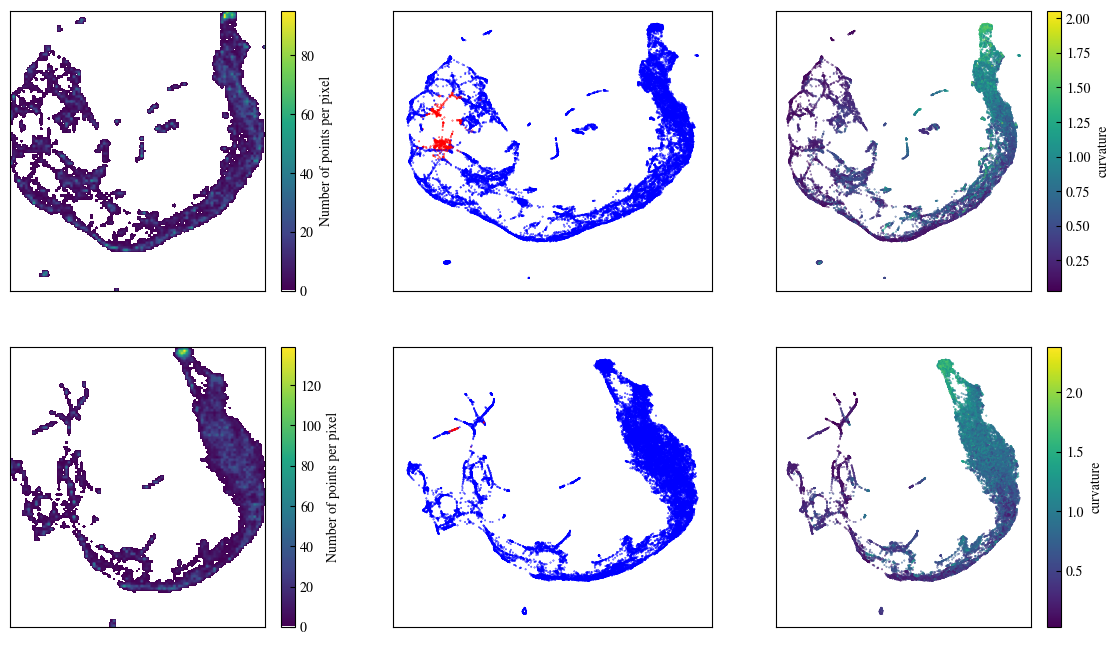

In [20]:
fig,ax = plt.subplots(nrows = mkvs.__len__(),ncols=3, figsize=(14,8),subplot_kw={'projection':'scatter_density'})

for i in range(mkvs.__len__()):
    mkvs[i].compute_spectrum()
    mkvs[i].reversibilized_matrix()
    mkvs[i].compute_tr_spectrum()

    curvature = np.array([average_curvature_angle(traj.reshape(-1,3)) for traj in embs[i].flatten_embedding_matrix])

    src.viz.use_mpl_scatter_density(fig,data[i][:,0],data[i][:,1],ax=ax[i,0],dpi=50)
    ax2 = ax[i,2].scatter(data[i][:,0],data[i][:,1],c=curvature,s=0.1,rasterized=True)#embs[i].labels,s=0.1)
    ax[i,1].scatter(data[i][:, 0],data[i][:, 1],c = mkvs[i].tr_slow_modes[:,-1][mkvs[i].labels],s=0.1,cmap='bwr',rasterized=True)
    fig.colorbar(ax2, label='curvature')

    for j in range(3):
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])